# Market Sentiment Predictor

Geovanni Jones, Josh Previte, Casey Barrasso

The goal of this project is to predict the directional price movement of a specific stock using both historical price data and news information. Two separate models will predict price movements based on historical data and analyze news sentiment.

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from collections import Counter

from statsmodels.tsa.seasonal import seasonal_decompose


In [105]:
os.getcwd()

'c:\\Users\\geova\\OneDrive\\Desktop\\Spring 2026 Classes\\Applied Analytics Project\\notebooks'

# Week 2 - Data Ingestion

There are two main datasets to this project. The first is a dataset containing news article content including titles, content, and sentiment scores from various news sources around the AAPL stock. The second dataset (introduced later in the notebook) contains a time series of AAPL stock prices. The final dataset will combine the two datasets on date.

## Sentiment Dataset

In [106]:
#Github didn't allow us to upload a file more than 25MB. This is combining all files into one file
raw_data_1 = pd.read_csv('../data/apple_news_data_1.csv', encoding='latin-1')
raw_data_2 = pd.read_csv('../data/apple_news_data_2.csv', encoding='latin-1')
raw_data_3 = pd.read_csv('../data/apple_news_data_3.csv', encoding='latin-1')
raw_data_4 = pd.read_csv('../data/apple_news_data_4.csv', encoding='latin-1')
raw_data_5 = pd.read_csv('../data/apple_news_data_5.csv', encoding='latin-1')

raw_data = pd.concat([raw_data_1, raw_data_2, raw_data_3, raw_data_4, raw_data_5])[['date', 'title', 'content', 'link', 'symbols', 'tags', 'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos']]

In [107]:
#view a small subsection of the data to ensure formatting looks correct
raw_data.head(10)

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2021-04-30T21:38:00+00:00,Techâs Big Five Had Fantastic Pandemics. Her...,"Alphabet, Amazon.com, Apple, Facebook, and Mic...",https://finance.yahoo.com/m/bbe3f7c9-c7af-3c9f...,"AAPL.US, AAPL34.SA, AMZN.US, FB.US, GOOGL.US","AMAZON, APPLE, FACEBOOK, HARLEY FINKELSTEIN, M...",0.395,0,0.871,0.129
1,2021-04-30T20:41:52+00:00,Valuation Remains a Concern for Churchill Capi...,Churchill Capital IV (NYSE:CCIV) stock has gra...,https://finance.yahoo.com/news/valuation-remai...,"AAPL.US, CCIV-UN.US, CCIV.US","BUSINESS COMBINATION, CCIV, CHURCHILL CAPITAL ...",0.998,0.023,0.85,0.127
2,2021-04-30T20:18:00+00:00,Big techâs trillion-dollar pandemic year may...,This week concludes the first quarter earnings...,https://finance.yahoo.com/m/6e441d74-37c1-3642...,"AAPL.US, AAPL34.SA, AMZN.US, MSFT.US","AMAZON, APPLE INC, BIG TECH, MARKET CAPITALIZA...",0,0,1,0
3,2021-04-30T19:32:30+00:00,What Appleâs blowout earnings means for Berk...,"Krish Sankar, Managing Dir. & Cowen Senior Res...",https://finance.yahoo.com/video/apple-blowout-...,"AAPL.US, AAPL34.SA, BRK-A.US, BRK-B.US, DJI.IN...","ALEXIS CHRISTOFOROUS, BERKSHIRE HATHAWAY, COWE...",0,0,1,0
4,2021-04-30T18:49:00+00:00,EU Agrees With Spotify: Apple Is Abusing Its A...,The EU's European Commission just released pre...,https://finance.yahoo.com/m/07524444-63a7-34aa...,"AAPL.US, AAPL34.SA, SPOT.US","APP STORE, APPLE, EUROPEAN COMMISSION, MUSIC S...",-0.71,0.093,0.885,0.022
5,2021-04-30T18:30:06+00:00,ETFs to Stack as Reopening Poses No Hindrance ...,The tech-heavyÂ Nasdaq Composite Index was a s...,https://finance.yahoo.com/news/etfs-stack-reop...,"AAPL.US, AAPL34.SA, COMP.US, FB.US, GOOGL.US, ...","APPLE, CONSENSUS ESTIMATE, EARNINGS PER SHARE,...",0.999,0.027,0.826,0.148
6,2021-04-30T18:19:10+00:00,Big Tech Stocks Flash Red Flag to Regulators A...,"If âBig Techâ was a gamefish, like Faceboo...",https://finance.yahoo.com/news/big-tech-stocks...,"AAPL.US, CRM.US, FB.US, GME.US, GOOGL.US, MSFT...","BITCOIN, DIGITAL TRANSFORMATION, FACEBOOK, MIC...",0.999,0.026,0.861,0.113
7,2021-04-30T18:13:06+00:00,"Top Stock Reports for Apple, Alphabet &amp; Bl...","Friday, April 30, 2021\n\nThe Zacks Research D...",https://finance.yahoo.com/news/top-stock-repor...,"AAPL.US, AAPL34.SA, BLK.US, F.US, GOOGL.US, ZT...","ALPHABET, APPLE, APPLE WATCH, BLACKROCK, RESEA...",0.999,0.042,0.775,0.183
8,2021-04-30T17:54:31+00:00,Why Stem Stock Looks Very Attractive Following...,"Not infrequently, Wall Street focuses excessiv...",https://finance.yahoo.com/news/why-stem-stock-...,"AAPL.US, AMZN.US, BX.US, FSLR.US, GE.US, GEOO3...","CLEAN-ENERGY, STEM STOCK",0.999,0.015,0.83,0.154
9,2021-04-30T17:34:59+00:00,âTechnology is the largest single growth tre...,"Keith Fitz-Gerald, Fitz-Gerald Group Chief Inv...",https://finance.yahoo.com/video/technology-lar...,"AAPL.US, AAPL34.SA, AMZN.US, DJI.INDX, FB.US, ...","ALEXIS CHRISTOFOROUS, KEITH FITZ-GERALD, SIBIL...",0,0,1,0


In [108]:
# Sort raw_data by date column from earliest to latest
raw_data = raw_data.sort_values('date', ascending=True).reset_index(drop=True)

#raw_data.head(10)
raw_data.tail(10)

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
35594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [109]:
#check how many NA values there are. We care most about sentiment, date, and content columns
raw_data.isna().sum().sort_values(ascending=False)

tags                  17790
sentiment_pos          5853
sentiment_neu          5812
sentiment_neg          5767
sentiment_polarity     5721
symbols                5539
link                   5340
content                4901
title                  4255
date                   2808
dtype: int64

In [110]:
#Drop Clumns we won't be focusing on (link and tags)
raw_data = raw_data.drop(columns=['link', 'tags'])

In [111]:
# force sentiment scores to be a numerical value, NA if not 
for col in ['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity']:
    raw_data[col] = pd.to_numeric(raw_data[col], errors='coerce')

# extract valid calendar dates only (ignore time + BST noise)
raw_data['date'] = pd.to_datetime(
    raw_data['date'].astype(str).str.extract(r'(\d{4}-\d{2}-\d{2})')[0],
    errors='coerce'
) #This section of the code was inputed to handle warnings from pandas that could lead to future breakage of the code.

# convert content to string
raw_data['content'] = raw_data['content'].astype('str')


In [112]:
# Setting "date" column to datetime format
raw_data['date'] = pd.to_datetime(raw_data['date'])

print(raw_data.shape)

#Data range for raw_data
print(f"Date range for raw_data: {raw_data['date'].min()} to {raw_data['date'].max()}")

(35604, 8)
Date range for raw_data: 2016-02-19 00:00:00 to 2024-11-27 00:00:00


In [113]:
#this data is messy, drop observations that have NAs in critical columns
raw_data = raw_data.dropna(subset=['sentiment_pos','sentiment_neu','sentiment_neg','sentiment_polarity','content','date'])

#print out the data type of each column to ensure conversions from above worked
for col in raw_data.columns:
    print(f'Column: {col} , Data Type: {raw_data[col].dtype}')

Column: date , Data Type: datetime64[ns]
Column: title , Data Type: object
Column: content , Data Type: object
Column: symbols , Data Type: object
Column: sentiment_polarity , Data Type: float64
Column: sentiment_neg , Data Type: float64
Column: sentiment_neu , Data Type: float64
Column: sentiment_pos , Data Type: float64


In [114]:
#Create a single sentiment score that we can use to determine if an article contains more negative or positive sentiment
raw_data['Net Sentiment'] = raw_data['sentiment_pos'] - raw_data['sentiment_neg']

#while not the main target variable, net sentiment could be interesting to determine presence of positive and negative language
#we can also make this a classification model by coverting to 'Positive', 'Neutral', or 'Negative' here.

The "content" column will be the predictor variable in the first model, and the string will be transformed into a numerical matrix using feature engineering methods such as TF-IDF. The "snetiment polarity" variable will be the target variable. The goal of the first model will be to predict the sentiment polarity of a news article given its content.

In [115]:
print(raw_data.shape)

(29700, 9)


In [116]:
# Dropping rows before January 1, 2018 and after October 31, 2024
raw_data = raw_data[(raw_data['date'] >= '2018-01-01') & (raw_data['date'] <= '2024-10-31')]

print(raw_data.shape)

#Data range for raw_data
print(f"Date range for raw_data: {raw_data['date'].min()} to {raw_data['date'].max()}")

(29635, 9)
Date range for raw_data: 2018-01-31 00:00:00 to 2024-10-31 00:00:00


This dataset has 29,638 rows and 10 columns (plus the net sentiment score column created by us)

## Price Timeseries Dataset

In [117]:
ts_data = pd.read_csv('../data/AAPL Stock Data.csv')

In [118]:
ts_data.head(10)

,Dates,AAPL Share Price
0,Jan-03-2005,1.13
1,Jan-04-2005,1.14
2,Jan-05-2005,1.15
3,Jan-06-2005,1.15
4,Jan-07-2005,1.24
5,Jan-10-2005,1.23
6,Jan-11-2005,1.15
7,Jan-12-2005,1.17
8,Jan-13-2005,1.25
9,Jan-14-2005,1.25


In [119]:
#check how many NA values there are
ts_data.isna().sum().sort_values(ascending=False)

Dates               0
AAPL Share Price    0
dtype: int64

In [120]:
#Convert values to the expected formatting
ts_data['Dates'] = pd.to_datetime(ts_data['Dates']).dt.date
ts_data['AAPL Share Price'] = ts_data['AAPL Share Price'].astype('float')

In [121]:
for col in ts_data.columns:
    print(f'Column: {col} , Data Type: {type(ts_data[col][0])}')

Column: Dates , Data Type: <class 'datetime.date'>
Column: AAPL Share Price , Data Type: <class 'numpy.float64'>


In [122]:
print(ts_data.shape)

(5298, 2)


In [123]:
# Setting "Dates" column to datetime format
ts_data['Dates'] = pd.to_datetime(ts_data['Dates'])

# Dropping rows before January 1, 2018 and after October 31, 2024
ts_data = ts_data[(ts_data['Dates'] >= '2018-01-01') & (ts_data['Dates'] <= '2024-10-31')]

print(ts_data.shape)
print(f"Date range: {ts_data['Dates'].min()} to {ts_data['Dates'].max()}")

(1720, 2)
Date range: 2018-01-02 00:00:00 to 2024-10-31 00:00:00


There are 1,720 rows in this dataset and two columns (date and price).

## Combining Datasets

In [124]:
# Recreate sentiment_data from raw_data to ensure clean state
sentiment_data = raw_data.groupby(['date'])[['sentiment_polarity']].mean()

# Create a complete date range from January 1, 2018 to October 31, 2024
date_range = pd.date_range(start='2018-01-01', end='2024-10-31', freq='D')
complete_dates = pd.DataFrame({'date': date_range})

# Reset index to make 'date' a column
sentiment_data = sentiment_data.reset_index()

# Convert to datetime
sentiment_data['date'] = pd.to_datetime(sentiment_data['date'])

# Merge with complete date range
sentiment_data = pd.merge(complete_dates, sentiment_data, on='date', how='left')

#Set index back to date column
sentiment_data = sentiment_data.set_index('date')

print(f"Sentiment data shape after filling missing dates: {sentiment_data.shape}")
sentiment_data.head(10)

Sentiment data shape after filling missing dates: (2496, 1)


,sentiment_polarity
date,
2018-01-01,NaN
2018-01-02,NaN
2018-01-03,NaN
2018-01-04,NaN
2018-01-05,NaN
2018-01-06,NaN
2018-01-07,NaN
2018-01-08,NaN
2018-01-09,NaN


In [125]:
#join on date
all_data = pd.merge(sentiment_data, ts_data, how = 'right', left_on = 'date', right_on = 'Dates')

In [126]:
for col in all_data.columns:
    print(f'Column: {col} , Data Type: {type(all_data[col][0])}')

Column: sentiment_polarity , Data Type: <class 'numpy.float64'>
Column: Dates , Data Type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
Column: AAPL Share Price , Data Type: <class 'numpy.float64'>


In [127]:
all_data.head(10)

,sentiment_polarity,Dates,AAPL Share Price
0,NaN,2018-01-02,43.07
1,NaN,2018-01-03,43.06
2,NaN,2018-01-04,43.26
3,NaN,2018-01-05,43.75
4,NaN,2018-01-08,43.59
5,NaN,2018-01-09,43.58
6,NaN,2018-01-10,43.57
7,NaN,2018-01-11,43.82
8,NaN,2018-01-12,44.27
9,NaN,2018-01-16,44.05


We have a greater amount of stock price data than news sentiment data on the AAPL stock. There are currently 5,298 rows and 3 columns, but only 1,574 rows have sentiment data (as shown from the print statement above). We can remove dates without any sentiment analysis at a future date. For right now, this data could be helpful for a traditional forecasting model

In [128]:
all_data['sentiment_polarity'].describe()

count    1112.000000
mean        0.531748
std         0.299017
min        -0.993000
25%         0.412746
50%         0.554172
75%         0.685809
max         1.000000
Name: sentiment_polarity, dtype: float64

The sentiment polarity looks to be performing as expected. Scores range from -.99 to 1.00, but most are positive (which is expected due to Apple's stellar performance during this time period.

All models will use next-day stock price direction as the main target variable. There will be three possible forecasting models, the traditional model will exclusively use previous stock prices as predictor variables, the second model exclusively uses sentiment analysis as the predictor variable, while the third model will combine both.

In [129]:
#Data range for all_data
print(f"Date range for all_data: {all_data['Dates'].min()} to {all_data['Dates'].max()}")

Date range for all_data: 2018-01-02 00:00:00 to 2024-10-31 00:00:00


# Week 3 - Split and EDA

This week, we will focus on splitting the data into a train, validation, and test set and performing exploratory data analysis (EDA).

## Split Sentiment Dataset

In [130]:
raw_data = raw_data.sort_values("date").reset_index(drop=True)

raw_train = raw_data[(raw_data["date"] >= "2018-01-01") & (raw_data["date"] <= "2022-10-31")]
raw_val   = raw_data[(raw_data["date"] >= "2022-11-01") & (raw_data["date"] <= "2023-10-31")]
raw_test  = raw_data[(raw_data["date"] >= "2023-11-01") & (raw_data["date"] <= "2024-10-31")]

print(raw_train.shape)
print(raw_val.shape)
print(raw_test.shape)

raw_train.head(10)

(15474, 9)
(7598, 9)
(6563, 9)


,date,title,content,symbols,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos,Net Sentiment
0,2018-01-31,Investor Expectations to Drive Momentum within...,"NEW YORK, Jan. 31, 2018 (GLOBE NEWSWIRE) -- ...","AAPL.US, AVHI.US, FARM.US, GM.US, SGRY.US",0.995,0.009,0.937,0.054,0.045
1,2018-03-16,Top 100 Reputable Companies Around the Globe A...,"Boston, MA, March 16, 2018 (GLOBE NEWSWIRE) ...","AAPL.US, AMZN.US, BA.US, BUD.US, CAJ.US, CAT.U...",0.991,0.011,0.917,0.072,0.061
2,2018-03-27,Universal Display Corporation Stock Is Way Und...,"Since topping out in January, shares of Univer...","AAPL.US, OLED.US",-0.244,0.134,0.764,0.101,-0.033
3,2018-04-16,Detailed Research: Economic Perspectives on Ge...,"NEW YORK, April 16, 2018 (GLOBE NEWSWIRE) --...","AAPL.US, FB.US, GD.US, GRMN.US, HD.US, WBA.US",0.997,0.008,0.930,0.062,0.054
4,2018-06-22,"Apple iPhone Spared Tariffs, But Could Face Ch...",In an escalating trade war between China and t...,"AAPL.US, HNHPF.US",-0.807,0.138,0.862,0.000,-0.138
5,2018-10-23,Report: Exploring Fundamental Drivers Behind T...,"NEW YORK, Oct. 23, 2018 (GLOBE NEWSWIRE) -- ...","AAPL.US, BTX.US, CTLT.US, HD.US, PDLI.US, QURE.US",0.995,0.008,0.941,0.051,0.043
6,2018-11-30,"New Research Coverage Highlights Omeros, Apple...","NEW YORK, Nov. 30, 2018 (GLOBE NEWSWIRE) -- ...","AAPL.US, BIO.US, COT.US, DAR.US, OMER.US, OR.US",0.998,0.009,0.925,0.066,0.057
7,2019-01-03,"Apple, AAPL Investment Losses Alert: Bernstein...","NEW YORK, Jan. 02, 2019 (GLOBE NEWSWIRE) -- ...",AAPL.US,0.992,0.038,0.816,0.147,0.109
8,2019-01-03,"SHAREHOLDER ALERT: Bronstein, Gewirtz & Grossm...","NEW YORK, Jan. 03, 2019 (GLOBE NEWSWIRE) -- ...",AAPL.US,0.967,0.050,0.839,0.111,0.061
9,2019-02-22,"Factors of Influence in 2019, Key Indicators a...","NEW YORK, Feb. 22, 2019 (GLOBE NEWSWIRE) -- ...","AAPL.US, CBAY.US, FTK.US, GVA.US, IMGN.US, UAL.US",0.997,0.009,0.928,0.064,0.055


## EDA Sentiment Dataset

Visual Analysis:

- Sentiment polarity distribution histogram
- Sentiment scores comparison (neg/neu/pos) boxplot
- Articles count over time (monthly trend)
- Average sentiment polarity over time with zero baseline

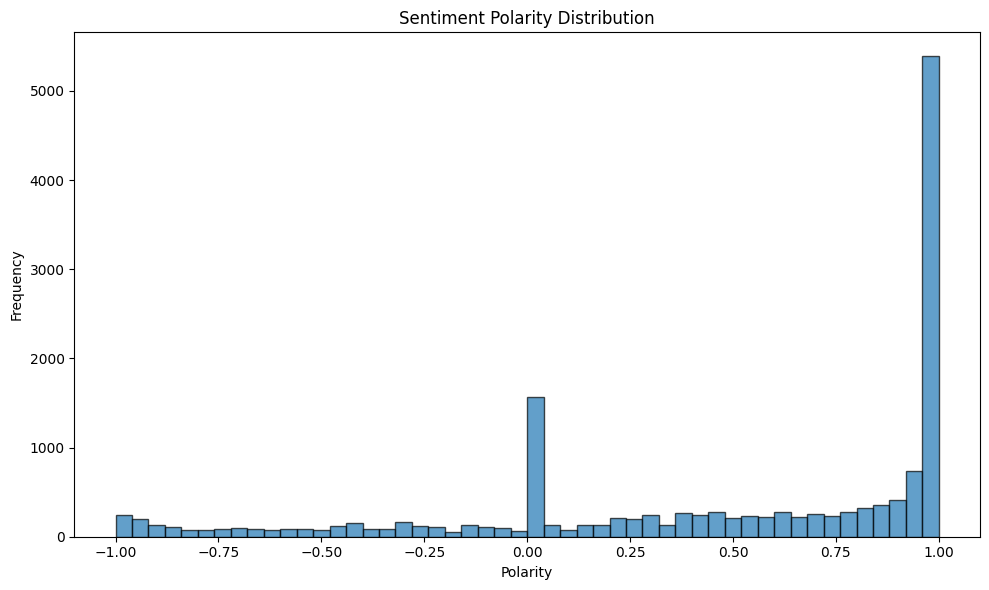

In [131]:
# Sentiment polarity distribution
plt.figure(figsize=(10, 6))
plt.hist(raw_train['sentiment_polarity'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

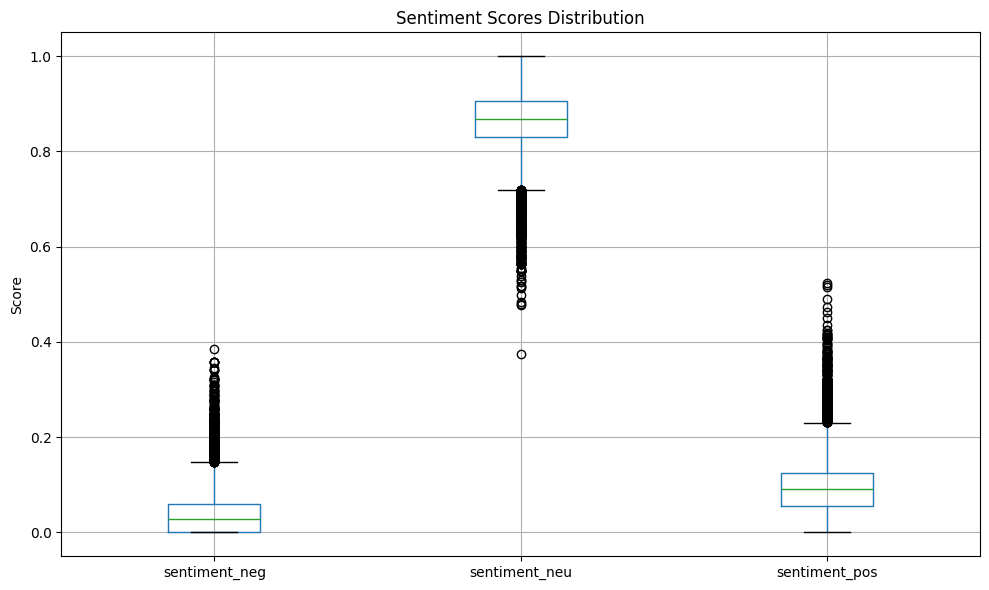

In [132]:
# Sentiment scores comparison
plt.figure(figsize=(10, 6))
sentiment_cols = ['sentiment_neg', 'sentiment_neu', 'sentiment_pos']
raw_train[sentiment_cols].boxplot()
plt.title('Sentiment Scores Distribution')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

C:\Users\geova\AppData\Local\Temp\ipykernel_4284\3404307298.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_train['date'] = pd.to_datetime(raw_train['date'])


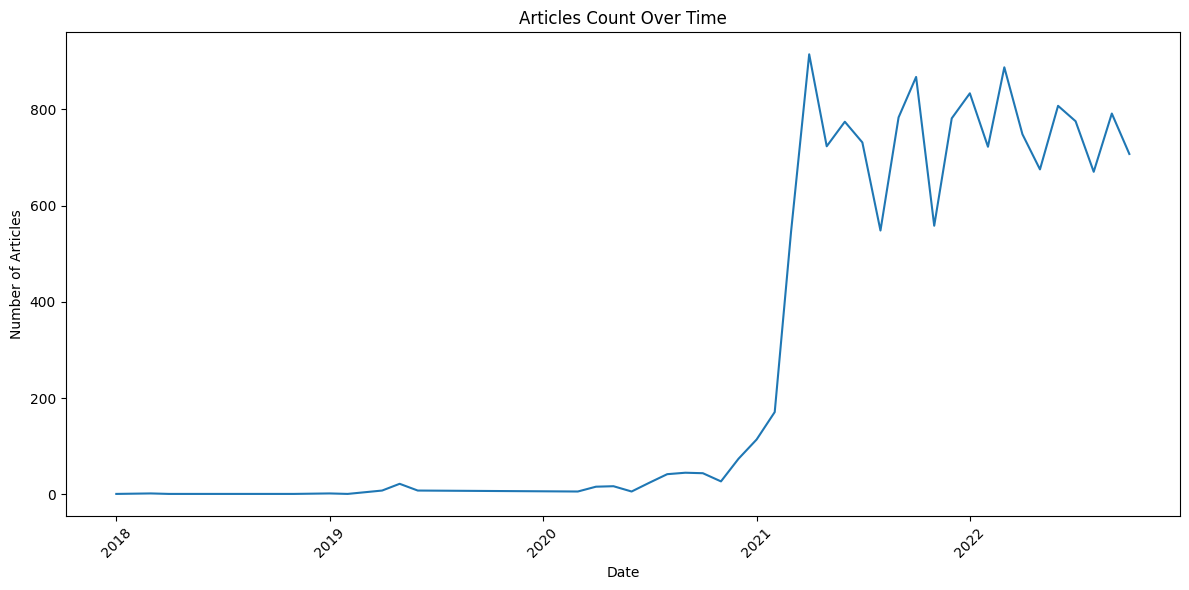

In [133]:
# Articles per date
raw_train['date'] = pd.to_datetime(raw_train['date'])
articles_per_date = raw_train.groupby(raw_train['date'].dt.to_period('M')).size()
plt.figure(figsize=(12, 6))
plt.plot(articles_per_date.index.to_timestamp(), articles_per_date.values)
plt.title('Articles Count Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

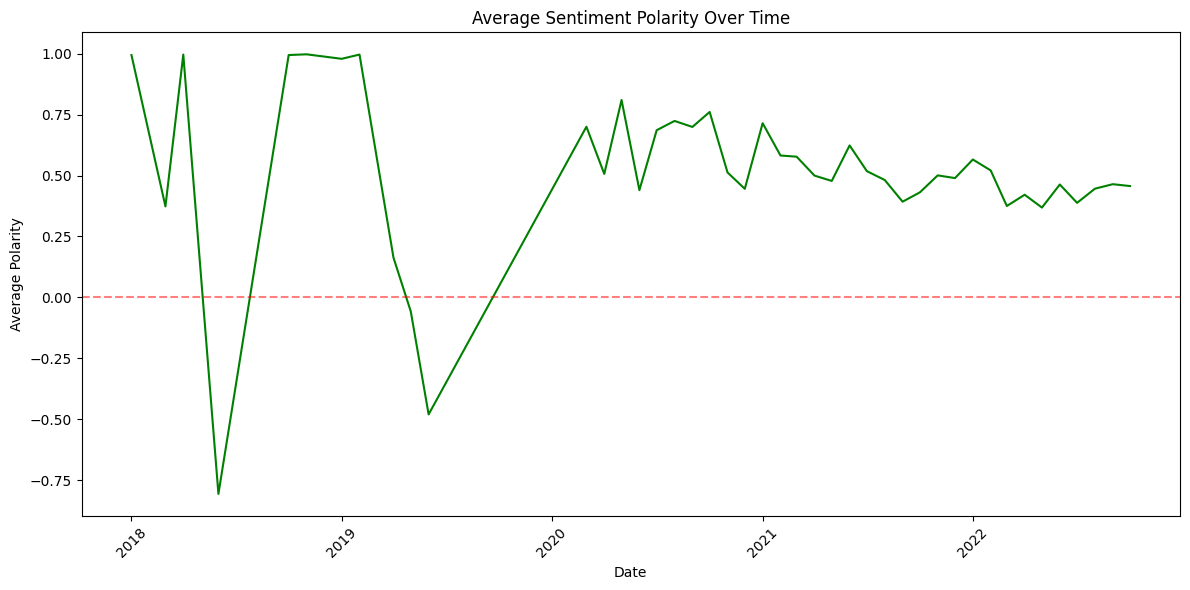

In [134]:
# Average sentiment over time
avg_sentiment = raw_train.groupby(raw_train['date'].dt.to_period('M'))['sentiment_polarity'].mean()
plt.figure(figsize=(12, 6))
plt.plot(avg_sentiment.index.to_timestamp(), avg_sentiment.values, color='green')
plt.title('Average Sentiment Polarity Over Time')
plt.xlabel('Date')
plt.ylabel('Average Polarity')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NLP Analysis on Title:

- Character length and word count distributions
- Average statistics

C:\Users\geova\AppData\Local\Temp\ipykernel_4284\1666406537.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_train['title_length'] = raw_train['title'].fillna('').str.len()                 # Title word count


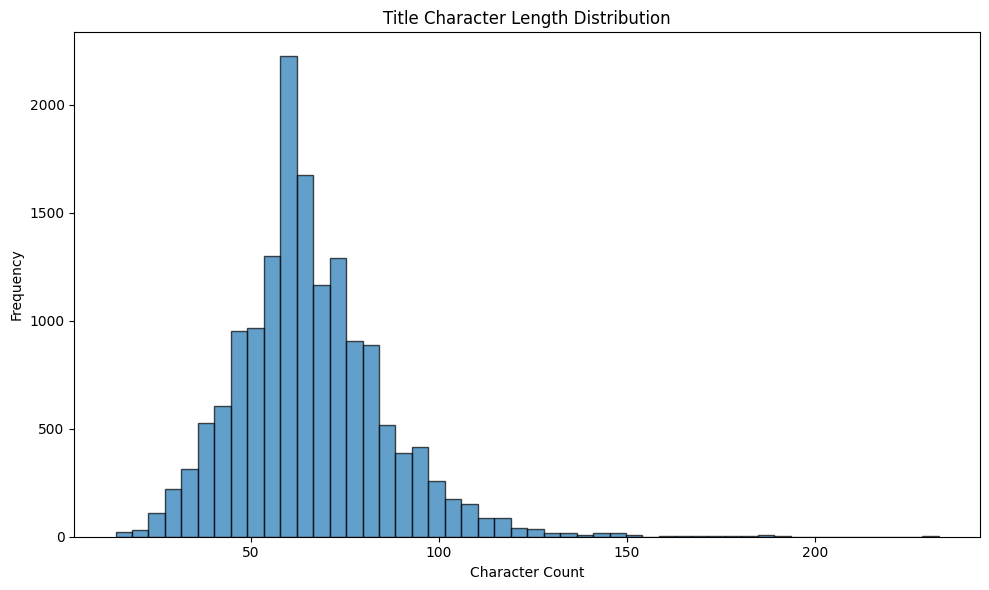


Average title length: 65.83 characters


In [135]:
# Title length distribution
raw_train['title_length'] = raw_train['title'].fillna('').str.len()                 # Title word count

# Title character length
plt.figure(figsize=(10, 6))
plt.hist(raw_train['title_length'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Title Character Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nAverage title length: {raw_train['title_length'].mean():.2f} characters")

C:\Users\geova\AppData\Local\Temp\ipykernel_4284\4066365091.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_train['title_word_count'] = raw_train['title'].fillna('').str.split().str.len()


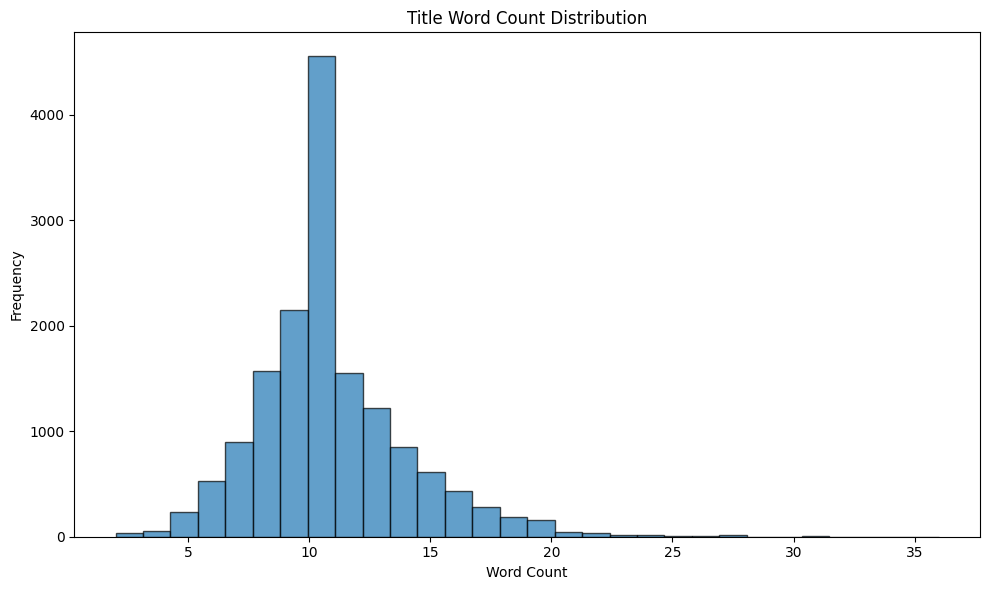

Average title word count: 10.85 words


In [136]:
# Title word count
raw_train['title_word_count'] = raw_train['title'].fillna('').str.split().str.len()

# Title word count
plt.figure(figsize=(10, 6))
plt.hist(raw_train['title_word_count'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Title Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average title word count: {raw_train['title_word_count'].mean():.2f} words")

- Top 20 most common words
- NLP Analysis on Content:

Character length and word count distributions
Average statistics and missing content count
Correlation Analysis:

Sentiment vs title/content length scatter plots

In [137]:
# Most common words in titles
all_title_words = ' '.join(
    raw_train['title']
    .fillna('')
    .astype(str)   # AI Added code to help prevent code breakage in future due to warning errors.
).lower()

words = re.findall(r'\b[a-z]+\b', all_title_words)
word_freq = Counter(words)
common_words = word_freq.most_common(20)

print("\nTop 20 most common words in titles:")
for word, count in common_words:
    print(f"  {word}: {count}")


Top 20 most common words in titles:
  apple: 5885
  to: 5033
  s: 3821
  stocks: 2929
  the: 2874
  in: 2615
  stock: 2316
  and: 1933
  on: 1873
  as: 1798
  for: 1730
  buy: 1617
  of: 1600
  a: 1587
  is: 1494
  tech: 1490
  market: 1359
  dow: 1321
  earnings: 1098
  with: 973


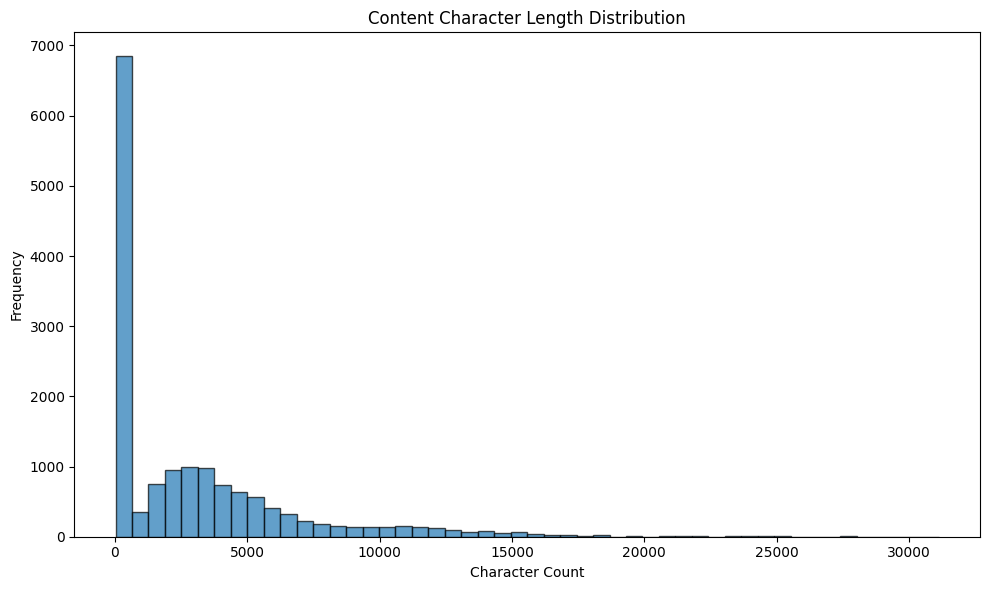


Average content length: 3020.90 characters


In [ ]:
# Content length distribution
raw_train.loc[:, 'content_length'] = (
    raw_train['content']
    .fillna('')
    .astype(str)
    .str.len()
) # AI Added code to help prevent code breakage in future due to warning errors.

# Content character length
plt.figure(figsize=(10, 6))
plt.hist(raw_train['content_length'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Content Character Length Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nAverage content length: {raw_train['content_length'].mean():.2f} characters")

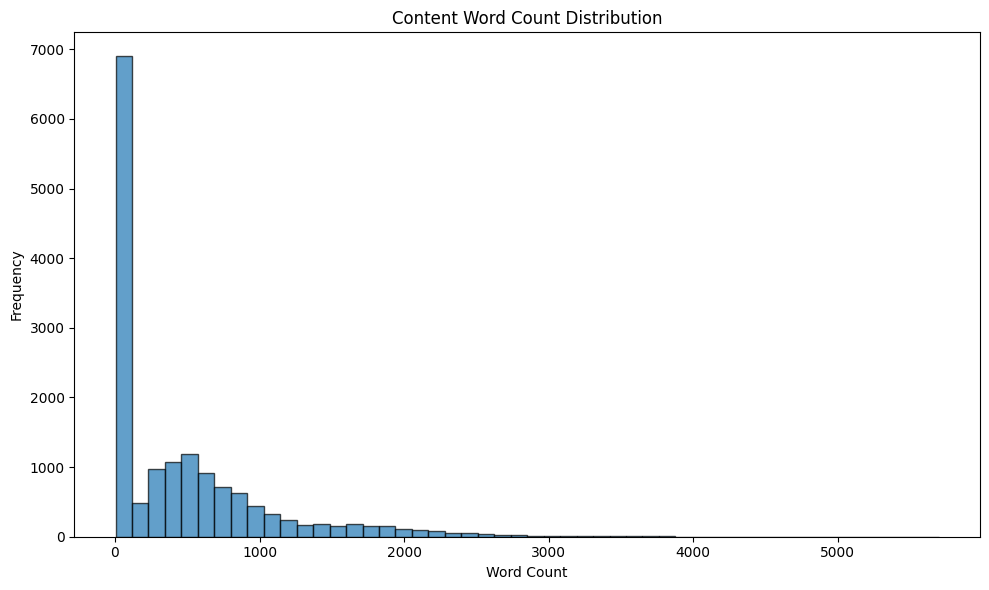

Average content word count: 481.55 words


In [151]:
# Content word count
raw_train.loc[:, 'content_word_count'] = (
    raw_train['content']
    .fillna('')
    .astype(str)
    .str.split()
    .str.len()
) # AI Added code to help prevent code breakage in future due to warning errors.

# Content word count distribution
plt.figure(figsize=(10, 6))
plt.hist(raw_train['content_word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Content Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average content word count: {raw_train['content_word_count'].mean():.2f} words")

In [144]:
print(f"Missing content: {raw_train['content'].isna().sum()} articles")

Missing content: 0 articles


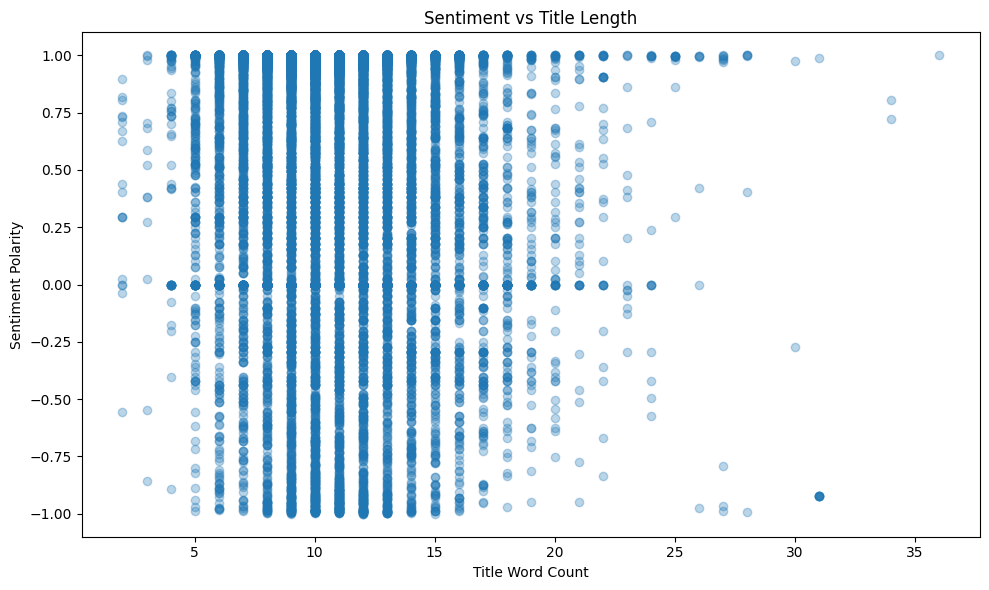

In [145]:
# Sentiment vs Title Length
plt.figure(figsize=(10, 6))
plt.scatter(raw_train['title_word_count'], raw_train['sentiment_polarity'], alpha=0.3)
plt.title('Sentiment vs Title Length')
plt.xlabel('Title Word Count')
plt.ylabel('Sentiment Polarity')
plt.tight_layout()
plt.show()

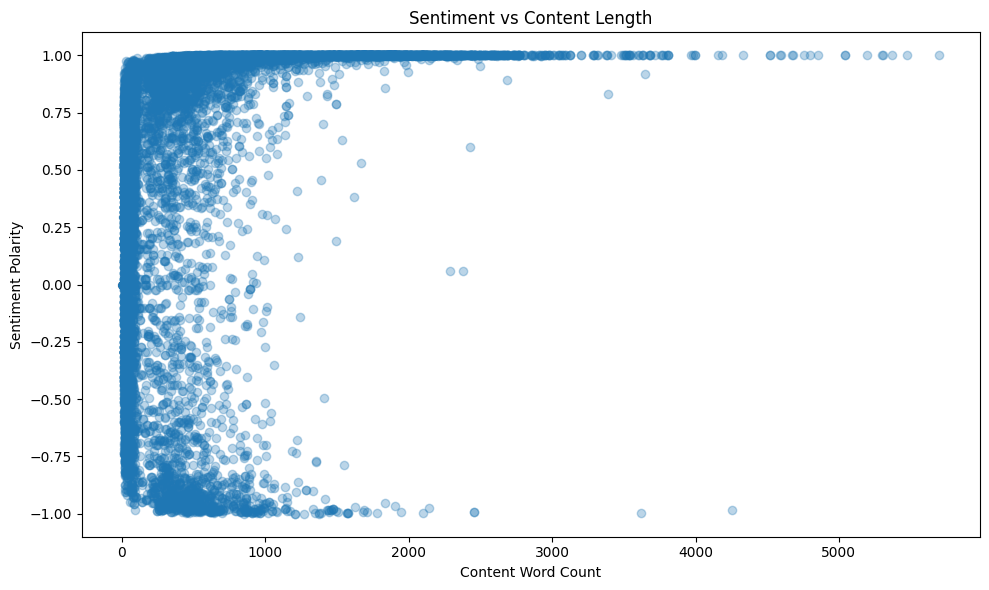

In [146]:
# Sentiment vs Content Length
plt.figure(figsize=(10, 6))
plt.scatter(raw_train['content_word_count'], raw_train['sentiment_polarity'], alpha=0.3)
plt.title('Sentiment vs Content Length')
plt.xlabel('Content Word Count')
plt.ylabel('Sentiment Polarity')
plt.tight_layout()
plt.show()

## Split Price Dataset

In [ ]:
ts_data = ts_data.sort_values("Dates").reset_index(drop=True)

ts_train = ts_data[(ts_data["Dates"] >= "2018-01-01") & (ts_data["Dates"] <= "2022-10-31")]
ts_val   = ts_data[(ts_data["Dates"] >= "2022-11-01") & (ts_data["Dates"] <= "2023-10-31")]
ts_test  = ts_data[(ts_data["Dates"] >= "2023-11-01") & (ts_data["Dates"] <= "2024-10-31")]

print(ts_train.shape)
print(ts_val.shape)
print(ts_test.shape)

ts_train.head(10)

## EDA Price Dataset

## Split Combined Dataset

In [ ]:
all_data["Dates"] = pd.to_datetime(all_data["Dates"])
all_data = all_data.sort_values("Dates").reset_index(drop=True)

com_train = all_data[(all_data["Dates"] >= "2018-01-01") & (all_data["Dates"] <= "2022-10-31")]
com_val   = all_data[(all_data["Dates"] >= "2022-11-01") & (all_data["Dates"] <= "2023-10-31")]
com_test  = all_data[(all_data["Dates"] >= "2023-11-01") & (all_data["Dates"] <= "2024-10-31")]

Now, we have three seperate sets of data. To prevent data leakage, all data processing will be done to each set seperately. Next, we will perform EDA on only the training data.

First, we build a plot using only the time series stock price data.

## EDA Combined Dataset (Training Data)

In [ ]:
plt.plot(com_train['Dates'], com_train['AAPL Share Price'])
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.title('Daily AAPL Share Price (Train Data)')
plt.gcf().autofmt_xdate()
plt.show()

During the period of time covered by the train data, AAPL stock fluctuates, but increases overall from July, 2020 to about January 2022. Then, it continues to flucctuate but trends down until July, 2022.

We can also build a plot of the sentiment polarity over the same period of time and compare the two charts.

In [ ]:
plt.plot(com_train['Dates'], com_train['sentiment_polarity'])
plt.xlabel('Date')
plt.ylabel('Sentiment Polarity')
plt.title('Daily Sentiment Polarity (Train Data)')
plt.gcf().autofmt_xdate()
plt.show()

The sentiment polarity plot shows some extreme highs and lows in the early months of the train data. Many of these are close to 1 (maximum) and -1 (minimum) and a few are exaclty 1.

There are some low outliers in 2020. These could be explained by the COVID-19 pandemic, which brought uncertainty to the stock market and the economy as a whole.

Most of the sentiment scores, especially in the latter half, are overall positive. It is also evident from the chart that there are several missing values, especially in the first few months. These will be important to address before modeling.

Also, since we know that sentiment polarity scores in this dataset are all in the -1 to 1 range, we can confirm that there are no illogical values in the train data by looking at this plot.

Next, we can examine the extent of missing values, specifically within the sentiment polarity feature.

In [ ]:
com_train['sentiment_polarity'].isna().sum()

Overall, there are 46 missing values for sentiment polarity within the train data and no missing values for AAPL stock price. Next, we can visualize where exactly these missing values occur in the time series data.

In [ ]:
plt.figure(figsize=(12,3))
plt.plot(
    com_train['Dates'],
    com_train['sentiment_polarity'].isna(),
    marker='o',
    linestyle='None'
)
plt.title("Missing Sentiment Polarity Over Time")
plt.xlabel("Date")
plt.ylabel("Missing? (True/False)")
plt.show()

As expected form the previous plot, most of the 46 missing values occur in the earlier months of the train data. 

We can also view a correlation matrix to look at how our two variables are correlated.

In [ ]:
corr_matrix = com_train[["sentiment_polarity", "AAPL Share Price"]].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
y = com_train['sentiment_polarity'].dropna()

decomp = seasonal_decompose(y, model='additive', period=7)
decomp.plot()
plt.gcf().set_size_inches(8, 5)
plt.show()